# Лабораторная работа 1

**Тема:** анализ научных публикаций о методах прогнозирования интенсивности и скорости дорожного движения.


## 1. Критерии отбора

- Публикации на arXiv с 01.01.2020 по 13.09.2026.
- Прогноз интенсивности/объёма потока или средней скорости на дорогах. (достаточно одного показателя)
- Включаю также обзоры и исследования качества профильных моделей. Обзоры отмечаю отдельно.
- Одна запись на arXiv ID. Решения и краткие заметки — в `data/screening.csv`.


In [1]:
from pathlib import Path
from datetime import datetime, timezone
from urllib.parse import urlencode
from urllib.request import Request, urlopen
import xml.etree.ElementTree as ET
import csv
import hashlib
import json
import re
import time
from collections import Counter

PROJECT = Path.cwd()
if not (PROJECT / "data").is_dir():
    PROJECT = PROJECT / "lab-1"
DATA = PROJECT / 'data'
RAW = DATA / 'raw'
RAW.mkdir(parents=True, exist_ok=True)
SEED = 42
print('Корпус и кеш:', DATA)
from urllib.error import HTTPError, URLError
from email.utils import parsedate_to_datetime
import random

import fcntl


Корпус и кеш: /Users/raul/ItmoProjects/Andan/lab-1/data


## 2. Поисковые фразы

Для поиска кандидатов в DataCite использовались варианты названия задачи: `traffic forecasting`, `traffic prediction`, `traffic flow prediction`, `traffic flow forecasting`, `traffic speed prediction`, `traffic speed forecasting`, `traffic volume prediction`, `traffic volume forecasting`.

Идентификаторы и даты первой публикации сохранены в `data/corpus_feasibility_datacite.json`; этот список использую для загрузки метаданных arXiv. Посторонние значения слова `traffic` исключаю при отборе.


## 3. Загрузка с кешированием и повторными попытками

Метаданные получаю через OAI-PMH arXiv / GetRecord. Сохраняю успешные ответы в кеш. Между запросами выдерживаю не менее 3 секунд; тайм-аут — 60 секунд. При HTTP 429 и временных сетевых ошибках выполняю до пяти попыток с учётом `Retry-After` или увеличивающейся паузой.

Прогресс сохраняю после каждой записи. Повторный запуск использует кеш; блокировка файла предотвращает одновременную работу двух сборщиков.


In [2]:
_last_request = 0.0

class DownloadUnavailable(RuntimeError):
    """Ожидаемая ошибка внешнего источника; сбор можно продолжить позже."""

MAX_ATTEMPTS = 5
COOLDOWN = RAW / 'retry_after.json'

def retry_delay(value, attempt):
    if value:
        try:
            return max(0.0, float(value))
        except ValueError:
            try:
                date = parsedate_to_datetime(value)
                if date.tzinfo is None:
                    date = date.replace(tzinfo=timezone.utc)
                return max(0.0, date.timestamp() - time.time())
            except (ValueError, TypeError, OverflowError):
                pass
    return 30 * 2 ** attempt + random.uniform(0, 3)



### Источники и охват

Поисковый `/api/query` возвращал ошибки 429/503. Поэтому идентификаторы нахожу через DataCite (`provider-id=arxiv`), а названия, авторов и аннотации загружаю через OAI-PMH arXiv / GetRecord.

[Доступ к arXiv](https://info.arxiv.org/help/bulk_data/index.html) · [OAI-PMH](https://info.arxiv.org/help/oa/index.html) · [DataCite](https://support.datacite.org/docs/api-queries)

Загружаю все 343 записи из списка `data/corpus_feasibility_datacite.json`. Статус `complete` означает завершение этого списка, а не полный охват темы на arXiv. Исходные ответы и URL сохраняю в кеше, прогресс — после каждой записи.

Дату первой публикации беру из DataCite `Submitted, v1` и записываю в `published`. Дату OAI `created` сохраняю отдельно в `oai_created`, расхождения отмечаю в `date_sources_differ`. OAI `datestamp` обозначает изменение метаданных, а не публикацию.


In [3]:
# Идентификаторы и даты беру из сохранённого списка DataCite.
# Тексты и авторов получаю непосредственно от arXiv через OAI-PMH.
OAI_API = 'https://oaipmh.arxiv.org/oai'
OAI_NS = {'o': 'http://www.openarchives.org/OAI/2.0/',
          'a': 'http://arxiv.org/OAI/arXiv/'}

def cached_oai(url):
    """Пауза, повторные попытки и кеш XML-ответов OAI-PMH."""
    global _last_request
    key = hashlib.sha256(url.encode()).hexdigest()[:24]
    cache = RAW / f'oai_{key}.xml'
    if cache.exists():
        return ET.fromstring(cache.read_bytes())
    for attempt in range(MAX_ATTEMPTS):
        deadline = json.loads(COOLDOWN.read_text()).get('not_before', 0) if COOLDOWN.exists() else 0
        pause = max(0, deadline-time.time(), 3.2-(time.monotonic()-_last_request))
        if pause > 3.2:
            print(f'Пауза: {pause:.0f} с', flush=True)
        time.sleep(pause)
        retry_after = None
        try:
            with urlopen(Request(url, headers={'User-Agent': 'AndanLab1Corpus/0.3 (academic study)'}), timeout=60) as r:
                payload = r.read()
            result = ET.fromstring(payload)
        except HTTPError as exc:
            status = exc.code
            retry_after = exc.headers.get('Retry-After') if exc.headers else None
            exc.close()
            if status not in {429, 500, 502, 503, 504}:
                raise DownloadUnavailable(f'OAI: HTTP {status}') from exc
            message = f'OAI: HTTP {status}'
        except (URLError, TimeoutError, ConnectionError) as exc:
            message = f'OAI: {exc}'
        except ET.ParseError as exc:
            raise DownloadUnavailable('OAI: вместо метаданных получен некорректный ответ') from exc
        else:
            cache.write_bytes(payload)
            cache.with_suffix('.source.json').write_text(json.dumps({
                'url': url, 'retrieved_at': datetime.now(timezone.utc).isoformat()
            }, ensure_ascii=False, indent=2), encoding='utf-8')
            return result
        finally:
            _last_request = time.monotonic()
        COOLDOWN.write_text(json.dumps({'not_before': time.time()+retry_delay(retry_after, attempt)}))
        print(f'{message}, попытка {attempt+1}/{MAX_ATTEMPTS}', flush=True)
    raise DownloadUnavailable(message)

def fetch_oai_record(arxiv_id):
    url = OAI_API + '?' + urlencode({'verb': 'GetRecord', 'identifier': f'oai:arXiv.org:{arxiv_id}', 'metadataPrefix': 'arXiv'})
    root = cached_oai(url)
    error = root.find('o:error', OAI_NS)
    if error is not None:
        raise DownloadUnavailable(f'OAI {error.get("code")}: {error.text}')
    a = root.find('.//a:arXiv', OAI_NS)
    if a is None:
        raise DownloadUnavailable(f'OAI: нет метаданных для {arxiv_id}')
    get = lambda tag: ' '.join(a.findtext('a:'+tag, default='', namespaces=OAI_NS).split())
    authors = []
    for author in a.findall('a:authors/a:author', OAI_NS):
        authors.append(' '.join(filter(None, [author.findtext('a:forenames', namespaces=OAI_NS), author.findtext('a:keyname', namespaces=OAI_NS)])))
    if get('id') != arxiv_id:
        raise DownloadUnavailable('ID полученной статьи не совпадает с запрошенным')
    return {'arxiv_id': arxiv_id, 'title': get('title'), 'abstract': get('abstract'),
            'authors': authors, 'published': get('created'), 'updated': get('updated') or get('created'),
            'categories': get('categories').split(), 'url': 'https://arxiv.org/abs/'+arxiv_id,
            'metadata_source': 'arXiv OAI-PMH', 'discovery_source': 'DataCite',
            'source_url': url}

def collect_shortlist():
    """Загружаю зафиксированный список, сохраняя прогресс после каждой статьи."""
    shortlist_path = DATA / 'corpus_feasibility_datacite.json'
    raw_shortlist = shortlist_path.read_bytes()
    shortlist = json.loads(raw_shortlist)
    ids = []
    discovery = {}
    for candidate in shortlist['candidates']:
        match = re.fullmatch(r'10\.48550/arxiv\.(\d{4}\.\d{4,5})(?:v\d+)?', candidate['id'].lower())
        if not match:
            raise ValueError('Неожиданный DOI в списке: '+candidate['id'])
        if match.group(1) not in ids:
            ids.append(match.group(1))
        discovery[match.group(1)] = candidate
    snapshot_hash = hashlib.sha256(raw_shortlist).hexdigest()
    dataset_path = DATA / 'candidates_oai_shortlist.json'
    manifest_path = DATA / 'candidates_oai_shortlist.manifest.json'
    rows, failed, rejected = [], [], []
    finished = False
    started = datetime.now(timezone.utc).isoformat()
    def save(status):
        manifest = dict(backend='datacite_shortlist_arxiv_oai', status=status,
                        complete=status=='complete', expected=len(ids), unique=len(rows),
                        processed=len(rows)+len(failed)+len(rejected),
                        failed=failed, rejected=rejected, started_at=started,
                        saved_at=datetime.now(timezone.utc).isoformat(),
                        shortlist_sha256=snapshot_hash, source_shortlist=shortlist_path.name,
                        candidates_file=dataset_path.name,
                        scope='Complete download of the preliminary shortlist; not final thematic approval')
        for path, obj in [(dataset_path,rows),(manifest_path,manifest)]:
            tmp=path.with_suffix(path.suffix+'.tmp')
            tmp.write_text(json.dumps(obj,ensure_ascii=False,indent=2),encoding='utf-8')
            tmp.replace(path)
        return manifest
    with (DATA/'collector.lock').open('a') as lock:
        try:
            fcntl.flock(lock, fcntl.LOCK_EX | fcntl.LOCK_NB)
        except BlockingIOError:
            print('Другой сборщик уже запущен.')
            return [], {'complete':False,'status':'busy'}
        try:
            for i, arxiv_id in enumerate(ids,1):
                r = fetch_oai_record(arxiv_id)
                r['oai_created'] = r['published']
                r['published'] = discovery[arxiv_id]['date']
                r['published_source'] = 'DataCite dates: Submitted, v1'
                r['date_sources_differ'] = r['published'][:10] != r['oai_created'][:10]
                if not ('2020-01-01' <= r['published'][:10] <= '2026-09-13'):
                    rejected.append({'arxiv_id':arxiv_id,'reason':'date outside selected period','published':r['published']})
                elif not r['title'] or not r['abstract'] or not r['authors']:
                    rejected.append({'arxiv_id':arxiv_id,'reason':'missing title/abstract/authors'})
                else:
                    rows.append(r)
                save('running')
                print(f'Загружено {len(rows)}/{len(ids)}; обработано {i}: {arxiv_id}',flush=True)
            finished = True
        except DownloadUnavailable as exc:
            failed.append({'arxiv_id':arxiv_id,'error':str(exc)})
            print('Сбор приостановлен:',exc,flush=True)
        except KeyboardInterrupt:
            failed.append({'arxiv_id':arxiv_id,'error':'Сбор прерван; можно продолжить с кешем.'})
            print('Сбор прерван, прогресс сохранён.',flush=True)
        finally:
            manifest=save('complete' if finished and not failed else 'paused')
            fcntl.flock(lock,fcntl.LOCK_UN)
    print(f'Сохранено {len(rows)} записей. Статус: {manifest["status"]}',flush=True)
    return rows,manifest


In [4]:
records, manifest = collect_shortlist()


Загружено 1/343; обработано 1: 2407.11074


Загружено 2/343; обработано 2: 2407.11407


Загружено 3/343; обработано 3: 2504.14248


Загружено 4/343; обработано 4: 2506.02609


Загружено 5/343; обработано 5: 2401.10155


...

Загружено 340/343; обработано 340: 2501.02008


Загружено 341/343; обработано 341: 2405.21045


Загружено 342/343; обработано 342: 2008.01902


Загружено 343/343; обработано 343: 2011.07728


Сохранено 343 записей. Статус: complete


## 4. Загруженные данные


In [5]:
print('Кандидатов:', len(records))
print('По годам:', dict(sorted(Counter(r['published'][:4] for r in records).items())))


Кандидатов: 343
По годам: {'2020': 37, '2021': 35, '2022': 49, '2023': 61, '2024': 67, '2025': 54, '2026': 40}


## 5. Корпус после отбора

В `data/screening.csv` указаны решения `include` / `exclude` и причины. Загружаю включённые статьи для дальнейшего анализа.


In [6]:
with (DATA / 'screening.csv').open(encoding='utf-8-sig', newline='') as f:
    screening = {row['arxiv_id']: row for row in csv.DictReader(f)}

assert all(r['arxiv_id'] in screening for r in records), 'Не для всех статей есть решение'
assert all(screening[r['arxiv_id']]['decision'] in {'include', 'exclude'} for r in records), 'Отбор не завершён'
corpus = [dict(r, is_review=screening[r['arxiv_id']]['is_review'])
          for r in records if screening[r['arxiv_id']]['decision'] == 'include']
corpus_ready = manifest['complete'] and len(corpus) >= 300
(DATA / 'corpus.json').write_text(json.dumps(corpus, ensure_ascii=False, indent=2), encoding='utf-8')
print(f'В корпусе: {len(corpus)}; исключено: {len(records) - len(corpus)}')
assert corpus_ready, 'Нужна полная загрузка и не менее 300 отобранных статей'


В корпусе: 318; исключено: 25


## 6. Разведочный анализ и закон Ципфа

Проверяю пропуски, повторы, распределения по годам, длине аннотаций и числу авторов.

Для подсчёта слов привожу текст к нижнему регистру, удаляю URL и команды LaTeX, выделяю последовательности латинских букв длиной от двух символов. Дефисы разделяют слова. Стоп-слова сохраняю, лемматизацию не применяю. Исходные тексты не изменяю.


In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

assert corpus_ready
papers = pd.DataFrame(corpus)
FIGURES = DATA / 'figures'
FIGURES.mkdir(exist_ok=True)
plt.rcParams.update({'font.family': 'DejaVu Sans', 'figure.dpi': 110,
                     'axes.spines.top': False, 'axes.spines.right': False})

def words(text):
    text = re.sub(r'https?://\S+|www\.\S+', ' ', text.lower())
    text = re.sub(r'\\[a-zA-Z]+', ' ', text)
    return re.findall(r'[a-z]{2,}', text)

def normalized_text(text):
    return ' '.join(re.findall(r'\w+', text.casefold()))

papers['year'] = pd.to_datetime(papers['published']).dt.year
papers['abstract_words'] = papers['abstract'].map(lambda text: len(words(text)))
papers['author_count'] = papers['authors'].map(len)
missing = {field: sum(not r.get(field) or
                     (isinstance(r[field], str) and not r[field].strip()) for r in corpus)
           for field in ['arxiv_id', 'title', 'abstract', 'authors', 'published']}
duplicates = {
    'arXiv ID': papers['arxiv_id'].duplicated().sum(),
    'Нормализованные названия': papers['title'].map(normalized_text).duplicated().sum(),
    'Нормализованные аннотации': papers['abstract'].map(normalized_text).duplicated().sum(),
}
print(f'Публикаций: {len(papers)}; обзорных: {(papers.is_review == "yes").sum()}')
print('Пропуски:', missing)
print('Повторные записи (после первого вхождения):', {k: int(v) for k, v in duplicates.items()})
display(papers[['abstract_words', 'author_count']].rename(columns={
    'abstract_words': 'Слов в аннотации', 'author_count': 'Авторов'
}).describe().round(1))

Matplotlib is building the font cache; this may take a moment.


Публикаций: 318; обзорных: 10
Пропуски: {'arxiv_id': 0, 'title': 0, 'abstract': 0, 'authors': 0, 'published': 0}
Повторные записи (после первого вхождения): {'arXiv ID': 0, 'Нормализованные названия': 0, 'Нормализованные аннотации': 0}


,Слов в аннотации,Авторов
count,318.0,318.0
mean,194.5,4.5
std,37.4,1.8
min,81.0,1.0
25%,171.0,3.0
50%,199.0,4.0
75%,218.0,6.0
max,287.0,10.0


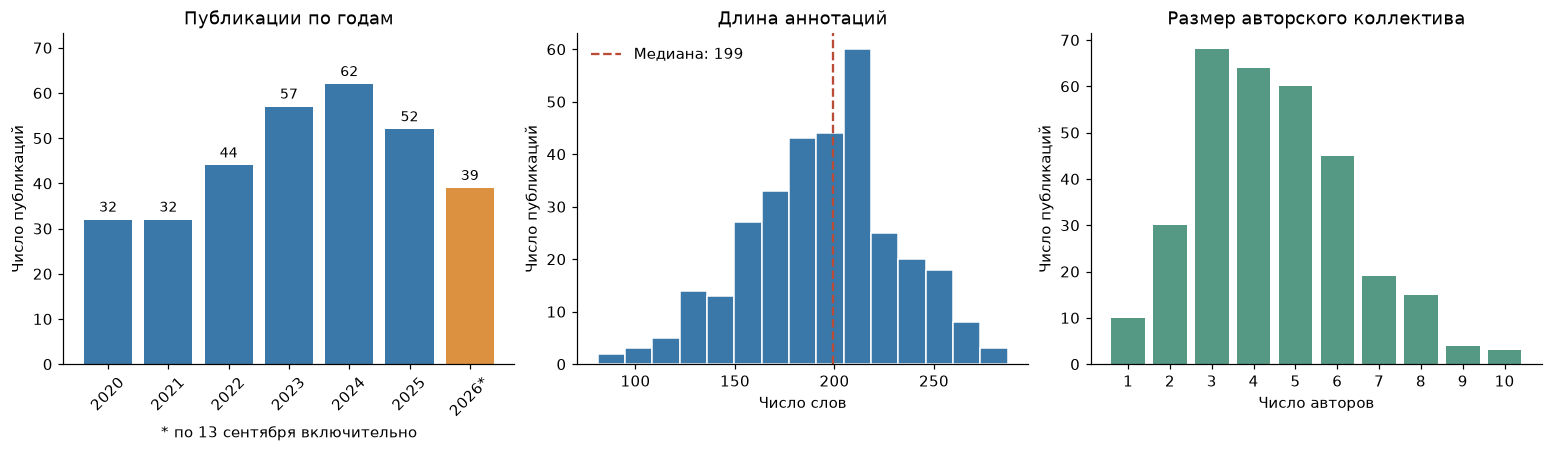

In [8]:
years = papers.groupby('year').size().reindex(range(2020, 2027), fill_value=0)
fig, axes = plt.subplots(1, 3, figsize=(14, 4), layout='constrained')
colors = ['#3978a8'] * 6 + ['#db9140']
bars = axes[0].bar(years.index, years.values, color=colors)
axes[0].bar_label(bars, padding=3, fontsize=9)
axes[0].set(title='Публикации по годам', ylabel='Число публикаций', ylim=(0, years.max() * 1.18))
axes[0].set_xticks(years.index, [str(y) if y < 2026 else '2026*' for y in years.index], rotation=45)
axes[0].set_xlabel('* по 13 сентября включительно')
axes[1].hist(papers.abstract_words, bins='fd', color='#3978a8', edgecolor='white')
axes[1].axvline(papers.abstract_words.median(), color='#ba4b36', linestyle='--',
                label=f'Медиана: {papers.abstract_words.median():.0f}')
axes[1].set(title='Длина аннотаций', xlabel='Число слов', ylabel='Число публикаций')
axes[1].legend(frameon=False)
author_counts = papers.author_count.value_counts().sort_index()
axes[2].bar(author_counts.index, author_counts.values, color='#559883')
axes[2].set(title='Размер авторского коллектива', xlabel='Число авторов', ylabel='Число публикаций')
axes[2].set_xticks(author_counts.index)
fig.savefig(FIGURES / 'corpus_eda.png', dpi=160, bbox_inches='tight')
plt.show()

### Частоты слов и закон Ципфа

Считаю вхождения слов в названиях и аннотациях, сортирую по убыванию частоты, при равенстве — по алфавиту.

Сравниваю распределение с законом Ципфа $f(r)\propto 1/r$. Для нормированной кривой использую $f_Z(r)=N/(H_Vr)$, где $N$ — число словоупотреблений, $V$ — размер словаря, $H_V=\sum_{r=1}^{V}1/r$.

На рангах 10–1000 оцениваю наклон линейной регрессией логарифмов. Ожидаемый наклон — −1.распределения.


Словоупотреблений: 65,411; уникальных слов: 4,626
Слова с одним вхождением: 1628 (35.2% словаря, 2.5% текста)
Доля 10 самых частых слов: 22.0%
Аппроксимация рангов 10–1000: наклон = -1.035, показатель α = 1.035, R²(log–log) = 0.996


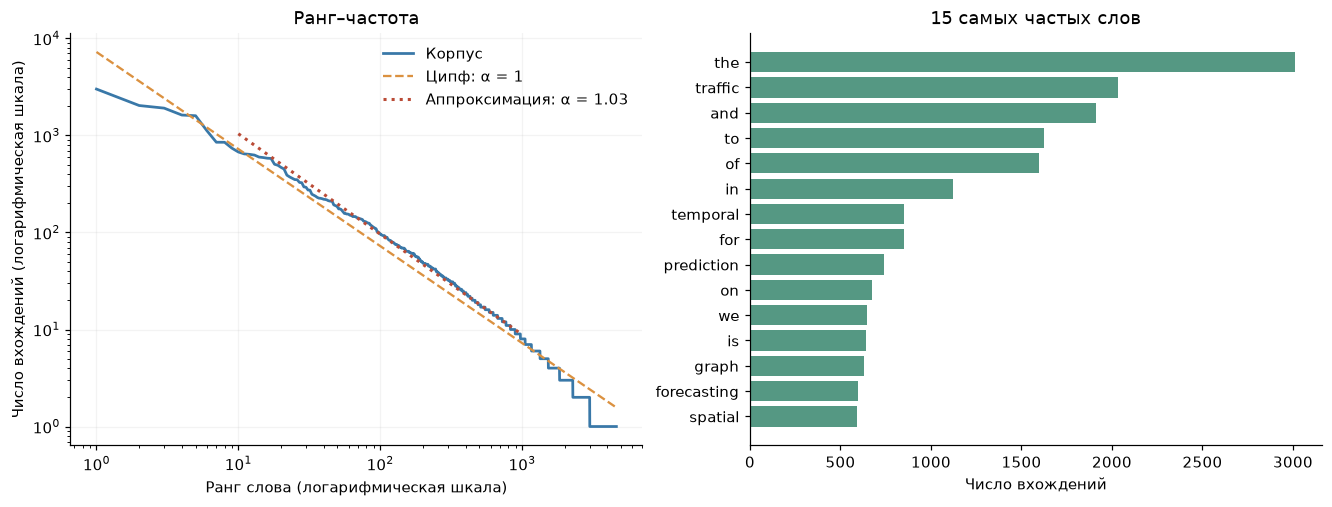

In [9]:
frequencies = Counter(word for r in corpus for word in words(r['title'] + ' ' + r['abstract']))
word_freq = pd.DataFrame(sorted(frequencies.items(), key=lambda pair: (-pair[1], pair[0])),
                         columns=['word', 'count'])
word_freq.insert(0, 'rank', np.arange(1, len(word_freq) + 1))
word_freq['share'] = word_freq['count'] / word_freq['count'].sum()
word_freq.to_csv(DATA / 'word_frequencies.csv', index=False)

ranks = word_freq['rank'].to_numpy()
counts = word_freq['count'].to_numpy()
N, V = int(counts.sum()), len(counts)
hapax = int((counts == 1).sum())
fit_mask = (ranks >= 10) & (ranks <= min(1000, V)) & (counts >= 2)
x, y = np.log10(ranks[fit_mask]), np.log10(counts[fit_mask])
slope, intercept = np.polyfit(x, y, 1)
fitted = slope * x + intercept
r_squared = 1 - np.sum((y - fitted)**2) / np.sum((y - y.mean())**2)
zipf_reference = N / (np.sum(1 / ranks) * ranks)

print(f'Словоупотреблений: {N:,}; уникальных слов: {V:,}')
print(f'Слова с одним вхождением: {hapax} ({hapax / V:.1%} словаря, {hapax / N:.1%} текста)')
print(f'Доля 10 самых частых слов: {counts[:10].sum() / N:.1%}')
print(f'Аппроксимация рангов {ranks[fit_mask][0]}–{ranks[fit_mask][-1]}: '
      f'наклон = {slope:.3f}, показатель α = {-slope:.3f}, R²(log–log) = {r_squared:.3f}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), layout='constrained')
axes[0].loglog(ranks, counts, color='#3978a8', linewidth=1.8, label='Корпус')
axes[0].loglog(ranks, zipf_reference, '--', color='#db9140', label='Ципф: α = 1')
axes[0].loglog(ranks[fit_mask], 10**fitted, ':', color='#ba4b36', linewidth=2,
               label=f'Аппроксимация: α = {-slope:.2f}')
axes[0].set(title='Ранг–частота', xlabel='Ранг слова (логарифмическая шкала)',
            ylabel='Число вхождений (логарифмическая шкала)')
axes[0].legend(frameon=False)
axes[0].grid(alpha=0.15)
top = word_freq.head(15).iloc[::-1]
axes[1].barh(top.word, top['count'], color='#559883')
axes[1].set(title='15 самых частых слов', xlabel='Число вхождений')
fig.savefig(FIGURES / 'zipf.png', dpi=160, bbox_inches='tight')
plt.show()

### Выводы

Получаю 318 публикаций. Пропусков в основных полях и повторов ID, нормализованных названий и аннотаций нет. Содержательно близкие работы эта проверка не исключает.

Больше всего статей в корпусе за 2024 год — 62. За 2026 год их 39, но данные собраны только по 13 сентября. Распределение зависит от запросов и отбора, поэтому не характеризует всю область.

Медианная длина аннотации — 199 слов, средняя — 194,5; половина значений лежит между 171 и 218. Медианное число авторов — 4, среднее — 4,5; чаще всего встречаются коллективы из трёх авторов.

В текстах 65 411 словоупотреблений и 4 626 разных слов. Десять самых частых занимают 22,0% текста. Однократные слова составляют 35,2% словаря и 2,5% текста.

На рангах 10–1000 получаю α = 1,035 и R² = 0,996: распределение близко к Ципфу. Самые частые слова отклоняются от нормированной кривой, а редкий хвост образует ступени.


## 7. Нормализация и ключевые слова

Сравниваю TF-IDF для униграмм без лемматизации, лемм, словосочетаний из 2–3 слов и смешанного словаря. Документ — название и аннотация статьи; название учитываю один раз. Использую сглаженный IDF, логарифмическую TF и L2-нормировку.

Привожу текст к нижнему регистру, удаляю URL и команды LaTeX, разделяю дефисы. WordNet объединяет формы существительных (`networks → network`), но не все формы слов. Сокращения не расшифровываю, слова с цифрами сохраняю.

Удаляю английские стоп-слова и общие научные слова. Словосочетания составляю из соседних слов, не соединяя их через удалённые слова и пунктуацию. `traffic` и `data` исключаю только как отдельные теги. Сравниваю `min_df=2` и `min_df=3`; верхний порог `max_df=0.30` — не более 30% статей (95 из 318). Он ограничивает частоту термина по документам, а не величину TF-IDF.

Для десяти тегов сначала выбираю до шести словосочетаний по TF-IDF, затем дополняю список из общего рейтинга. Вложенные варианты не дублирую. Поэтому порядок тегов может отличаться от порядка по весу; исходные веса сохраняю в CSV.


In [10]:
import nltk
from nltk.corpus import wordnet
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import TfidfVectorizer, ENGLISH_STOP_WORDS

nltk_dir = DATA / 'nltk_data'
nltk.data.path.insert(0, str(nltk_dir))
try:
    wordnet.ensure_loaded()
except LookupError:
    import subprocess, zipfile
    archive = nltk_dir / 'corpora' / 'wordnet.zip'
    archive.parent.mkdir(parents=True, exist_ok=True)
    temporary = archive.with_suffix('.download')
    subprocess.run(['curl', '--fail', '--location', '--silent', '--show-error',
                    '--connect-timeout', '15', '--max-time', '120', '--retry', '2',
                    'https://raw.githubusercontent.com/nltk/nltk_data/gh-pages/packages/corpora/wordnet.zip',
                    '--output', str(temporary)], check=True, timeout=400)
    with zipfile.ZipFile(temporary) as downloaded:
        assert downloaded.testzip() is None, 'Повреждён архив WordNet'
    temporary.replace(archive)
    wordnet.ensure_loaded()
lemmatizer = WordNetLemmatizer()
scientific_stop = set('paper study propose proposed present result results method methods approach approaches model models framework task tasks experiment experiments experimental demonstrate show performance effective effectiveness novel existing based using use used can also order especially manner perform comprehensive body latest achieve achieved achieves revealed verifies compared'.split())
stop_words = set(ENGLISH_STOP_WORDS) | scientific_stop
single_stop = {'traffic', 'data'}

def text_segments(text, normalize=True):
    text = re.sub(r'https?://\S+|www\.\S+|\\[a-zA-Z]+', ' ', text.lower())
    text = re.sub(r"[-–—]", " ", text)
    segments, current = [], []
    # Разделяю последовательность на знаках препинания и стоп-словах.
    for match in re.finditer(r'[a-z][a-z0-9]*|[^\w\s]+', text):
        token = match.group()
        if not re.fullmatch(r'[a-z][a-z0-9]*', token) or len(token) < 2 or token in stop_words:
            if current: segments.append(current)
            current = []
            continue
        token = lemmatizer.lemmatize(token, pos='n') if normalize else token
        if token in stop_words:
            if current: segments.append(current)
            current = []
        else:
            current.append(token)
    if current: segments.append(current)
    return segments

def term_analyzer(normalize, sizes):
    def analyze(text):
        terms = []
        for segment in text_segments(text, normalize):
            for size in sizes:
                for i in range(len(segment) - size + 1):
                    term = ' '.join(segment[i:i + size])
                    if size != 1 or term not in single_stop:
                        terms.append(term)
        return terms
    return analyze

texts = [r['title'] + '. ' + r['abstract'] for r in corpus]
settings = {
    'Слова без лемматизации': (False, (1,), 2),
    'Леммы': (True, (1,), 2),
    'Словосочетания': (True, (2, 3), 2),
    'Смешанный, min_df=2': (True, (1, 2, 3), 2),
    'Смешанный, min_df=3': (True, (1, 2, 3), 3),
}
MAX_DOCUMENT_FRACTION = 0.30
variants, comparison = {}, []
for name, (normalize, sizes, minimum) in settings.items():
    vectorizer = TfidfVectorizer(analyzer=term_analyzer(normalize, sizes),
                                min_df=minimum, max_df=MAX_DOCUMENT_FRACTION, sublinear_tf=True)
    matrix = vectorizer.fit_transform(texts)
    variants[name] = (vectorizer, matrix)
    comparison.append({'Вариант': name, 'Терминов': matrix.shape[1],
                       'Статей без терминов': int((matrix.getnnz(axis=1) == 0).sum()),
                       'Медиана терминов в статье': float(np.median(matrix.getnnz(axis=1)))})
display(pd.DataFrame(comparison).set_index('Вариант'))

,Терминов,Статей без терминов,Медиана терминов в статье
Вариант,,,
Слова без лемматизации,2346,0,62.5
Леммы,2094,0,58.5
Словосочетания,2164,0,30.0
"Смешанный, min_df=2",4258,0,90.0
"Смешанный, min_df=3",2508,0,78.0


In [11]:
# Сортирую по весу; при равных весах — по алфавиту.
def top_terms(vectorizer, matrix, index, limit=10):
    row = matrix.getrow(index)
    names = vectorizer.get_feature_names_out()
    candidates = sorted(zip(row.indices, row.data), key=lambda pair: (-pair[1], names[pair[0]]))
    # Сначала отбираю до шести словосочетаний, затем дополняю список.
    phrases = [(column, score) for column, score in candidates if ' ' in names[column]]
    preferred = []
    for column, score in phrases:
        term = ' ' + names[column] + ' '
        if not any(term in ' ' + names[old] + ' ' or ' ' + names[old] + ' ' in term for old, _ in preferred):
            preferred.append((column, score))
        if len(preferred) == min(6, limit): break
    selected = []
    for column, score in preferred + candidates:
        term = names[column]
        # Убираю вложенные варианты одного термина.
        padded = ' ' + term + ' '
        if any(padded in ' ' + old['term'] + ' ' or ' ' + old['term'] + ' ' in padded for old in selected):
            continue
        selected.append({'term': term, 'score': float(score)})
        if len(selected) == limit: break
    return selected

# Сравниваю варианты на одних и тех же четырёх статьях.
example_indices = []
for query in ['graph', 'transformer', 'federated', 'survey']:
    matches = [i for i, r in enumerate(corpus) if query in r['title'].lower() and i not in example_indices]
    if matches: example_indices.append(matches[0])
examples = []
for i in example_indices:
    for name, (vectorizer, matrix) in variants.items():
        examples.append({'arxiv_id': corpus[i]['arxiv_id'], 'title': corpus[i]['title'],
                         'variant': name,
                         'keywords': ', '.join(x['term'] for x in top_terms(vectorizer, matrix, i, 8))})
pd.DataFrame(examples).to_csv(DATA / 'keyword_comparison.csv', index=False)
# Вывожу пример итоговых тегов; полное сравнение сохраняю в CSV.
display(pd.DataFrame(examples).query("variant == 'Смешанный, min_df=2'")[['arxiv_id', 'keywords']].set_index('arxiv_id'))

,keywords
arxiv_id,
2401.10155,"time varying, traffic node, learning mechanism..."
2001.02908,"temporal transformer, transformer network, lon..."
2302.08658,"federated learning, traffic fluctuation, spati..."
2101.11174,"traffic forecasting problem, open data, graph ..."


In [12]:
selected_variant = 'Смешанный, min_df=2'
keyword_vectorizer, keyword_matrix = variants[selected_variant]
terms = keyword_vectorizer.get_feature_names_out()
document_frequency = np.asarray((keyword_matrix > 0).sum(axis=0)).ravel()
pd.DataFrame({'term': terms, 'document_frequency': document_frequency,
              'idf': keyword_vectorizer.idf_}).to_csv(DATA / 'keyword_vocabulary.csv', index=False)
article_keywords = []
for i, record in enumerate(corpus):
    article_keywords.append({'arxiv_id': record['arxiv_id'], 'title': record['title'],
                             'normalized_text': ' '.join(word for segment in text_segments(texts[i]) for word in segment),
                             'keywords': top_terms(keyword_vectorizer, keyword_matrix, i)})
(DATA / 'article_keywords.json').write_text(json.dumps(article_keywords, ensure_ascii=False, indent=2), encoding='utf-8')
pd.DataFrame([{'arxiv_id': row['arxiv_id'], 'title': row['title'], 'rank': rank,
               'keyword': item['term'], 'tfidf': item['score']}
              for row in article_keywords for rank, item in enumerate(row['keywords'], 1)]).to_csv(DATA / 'article_keywords.csv', index=False)
print(f'Размечено статей: {len(article_keywords)}; словарь: {len(terms)} терминов')
print('Число ключевых слов на статью:', dict(sorted(Counter(len(r['keywords']) for r in article_keywords).items())))

Размечено статей: 318; словарь: 4258 терминов
Число ключевых слов на статью: {10: 318}


### Выводы по ключевым словам

Выбираю смешанный вариант с `min_df=2`, `max_df=0.30`: 4 258 терминов и по десять тегов для всех 318 статей. Лемматизация сокращает словарь униграмм с 2 346 до 2 094; при `min_df=3` смешанный словарь уменьшается до 2 508 терминов, теряя в том числе `traffic fluctuation`.

Проверка верхних порогов 0,8 / 0,5 / 0,3 / 0,2 / 0,1 показала: переход к 0,5 не меняет итоговые теги; 0,3 удаляет из словаря 43 частых термина относительно 0,8, включая `network`, `prediction`, `traffic forecasting`. Более строгий порог 0,2 убирает уже `flow prediction`, а 0,1 — `traffic flow forecasting`. Оставляю 0,3 как умеренное ограничение. Квоту до шести словосочетаний сохраняю: без неё среди лидеров графа появляются общие `mean`, `st`, `channel`, а группы не становятся явно понятнее.

На четырёх примерах проверяю теги по аннотациям: `2401.10155` — `time varying`, `graph learning`; `2001.02908` — `temporal transformer`, `spatial temporal dependency`; `2302.08658` — `federated learning`, `central server`; `2101.11174` — `graph neural network`, `survey`, `open data`. Остались неполные фразы `head self`, `convolution neural`: фильтр частоты не исправляет границы выражений.

Теги сохраняю в `data/article_keywords.json` и `.csv`, сравнение вариантов — в `data/keyword_comparison.csv`, словарь — в `data/keyword_vocabulary.csv`.

## 8. Граф ключевых слов

Строю неориентированный граф по десяти тегам каждой статьи. Узел — термин; вес ребра — число статей, где оба термина выбраны тегами. Для расчётов сохраняю все связи.

Сообщества нахожу методом Louvain с весами, `resolution=0.5` и `seed=42`. Для сравнения разбиений модулярность рассчитываю при фиксированном `resolution=1`. Она сравнивает связи внутри сообществ с ожидаемыми в случайной модели, учитывающей силы узлов.

На полном графе считаю степень (долю соседей), взвешенную степень (сумму весов), PageRank и нормированное посредничество. Для точного расчёта кратчайших путей задаю расстояние `1 / weight`: сильная связь должна быть короткой.


In [13]:
import networkx as nx
from itertools import combinations

keyword_graph = nx.Graph()
for article in article_keywords:
    tags = sorted({item['term'] for item in article['keywords']})
    for term in tags:
        if term not in keyword_graph:
            keyword_graph.add_node(term, document_count=0)
        keyword_graph.nodes[term]['document_count'] += 1
    for left, right in combinations(tags, 2):
        if keyword_graph.has_edge(left, right):
            keyword_graph[left][right]['weight'] += 1
        else:
            keyword_graph.add_edge(left, right, weight=1)
for left, right, attributes in keyword_graph.edges(data=True):
    attributes['distance'] = 1.0 / attributes['weight']

COMMUNITY_RESOLUTION = 0.5
components = sorted(nx.connected_components(keyword_graph), key=len, reverse=True)
communities = sorted(nx.community.louvain_communities(keyword_graph, weight='weight',
                                                    resolution=COMMUNITY_RESOLUTION, seed=SEED),
                     key=lambda group: (-len(group), sorted(group)))
community_id = {term: i + 1 for i, group in enumerate(communities) for term in group}
nx.set_node_attributes(keyword_graph, community_id, 'community')
modularity = nx.community.modularity(keyword_graph, communities, weight='weight', resolution=1)
print(f'Узлов: {keyword_graph.number_of_nodes()}; рёбер: {keyword_graph.number_of_edges()}')
print(f'Компонент: {len(components)}; крупнейшая: {len(components[0])} узлов; изолированных: {nx.number_of_isolates(keyword_graph)}')
# Для сопоставимости разбиений считаю обычную модулярность при resolution=1.
print(f'Плотность: {nx.density(keyword_graph):.4f}; сообществ: {len(communities)}; модулярность: {modularity:.3f}')
print('Связей только по одной статье:', sum(d['weight'] == 1 for _, _, d in keyword_graph.edges(data=True)))

Узлов: 1999; рёбер: 14143
Компонент: 1; крупнейшая: 1999 узлов; изолированных: 0
Плотность: 0.0071; сообществ: 10; модулярность: 0.586
Связей только по одной статье: 13989


In [14]:
degree_centrality = nx.degree_centrality(keyword_graph)
strength = dict(keyword_graph.degree(weight='weight'))
pagerank = nx.pagerank(keyword_graph, weight='weight', alpha=0.85)
betweenness = nx.betweenness_centrality(keyword_graph, weight='distance', normalized=True)
centralities = pd.DataFrame([
    {'term': term, 'community': community_id[term],
     'document_count': keyword_graph.nodes[term]['document_count'],
     'degree_centrality': degree_centrality[term], 'strength': strength[term],
     'pagerank': pagerank[term], 'betweenness': betweenness[term]}
    for term in sorted(keyword_graph)
])
# Сопоставляю ранги, чтобы различать популярность и роль посредника.
for metric in ['degree_centrality', 'strength', 'pagerank', 'betweenness']:
    centralities[metric + '_rank'] = centralities[metric].rank(method='min', ascending=False).astype(int)
centralities.to_csv(DATA / 'keyword_centralities.csv', index=False)
role_examples = ['long term traffic', 'traffic flow forecasting', 'short term traffic',
                 'recurrent neural', 'graph convolutional network', 'long range']
display(centralities.set_index('term').loc[role_examples,
        ['document_count', 'degree_centrality_rank', 'strength_rank', 'pagerank_rank', 'betweenness_rank']]
        .rename(columns={'document_count': 'Статей с тегом', 'degree_centrality_rank': 'Ранг степени',
                         'strength_rank': 'Ранг суммы весов', 'pagerank_rank': 'Ранг PageRank',
                         'betweenness_rank': 'Ранг посредничества'}))
community_rows = []
for i, group in enumerate(communities, 1):
    internal = keyword_graph.subgraph(group)
    ranked = sorted(group, key=lambda term: (-pagerank[term], term))
    covered = sum(any(k['term'] in group for k in article['keywords']) for article in article_keywords)
    community_rows.append({'community': i, 'nodes': len(group), 'articles': covered,
                           'internal_weight': int(internal.size(weight='weight')),
                           'top_terms': ', '.join(ranked[:8])})
community_summary = pd.DataFrame(community_rows)
community_summary.to_csv(DATA / 'keyword_communities.csv', index=False)
display(community_summary[['community', 'nodes', 'articles', 'top_terms']].head(10))
# Теги одной статьи могут относиться к разным сообществам.
pd.DataFrame([{'source': a, 'target': b, 'weight': d['weight'], 'distance': d['distance']}
              for a, b, d in keyword_graph.edges(data=True)]).to_csv(DATA / 'keyword_edges.csv', index=False)
nx.write_gexf(keyword_graph, DATA / 'keyword_graph.gexf')

,Статей с тегом,Ранг степени,Ранг суммы весов,Ранг PageRank,Ранг посредничества
term,,,,,
long term traffic,11,1,1,1,1
traffic flow forecasting,9,3,3,3,6
short term traffic,8,6,5,6,3
recurrent neural,6,18,13,18,10
graph convolutional network,6,20,13,16,12
long range,5,36,22,34,19


,community,nodes,articles,top_terms
0,1,514,166,"long term traffic, flow prediction, traffic fl..."
1,2,235,86,"large language, relation, cross city, llm, urb..."
2,3,219,86,"net, short term traffic, term traffic flow, co..."
3,4,200,75,"gnn, spatio temporal traffic, stgnns, temporal..."
4,5,185,79,"transportation network, traffic speed predicti..."
5,6,163,72,"graph convolutional network, spatial correlati..."
6,7,159,57,"second, diffusion, adaptation, cross domain, a..."
7,8,159,57,"traffic volume, expert, hand, fluctuation, mea..."
8,9,110,35,"decision making, survey, online, generalizatio..."
9,10,55,24,"time series, graph convolution network, factor..."


### Визуализация

Показываю 60 узлов с наибольшим PageRank и все связи между ними. Цвет узла — сообщество, площадь — число статей с тегом (160 пунктов² на статью). Подписываю 20 ведущих узлов.

Оранжевые рёбра встречаются минимум в двух статьях. Spring layout задаёт только расположение рисунка: геометрическое расстояние не равно длине пути в графе.


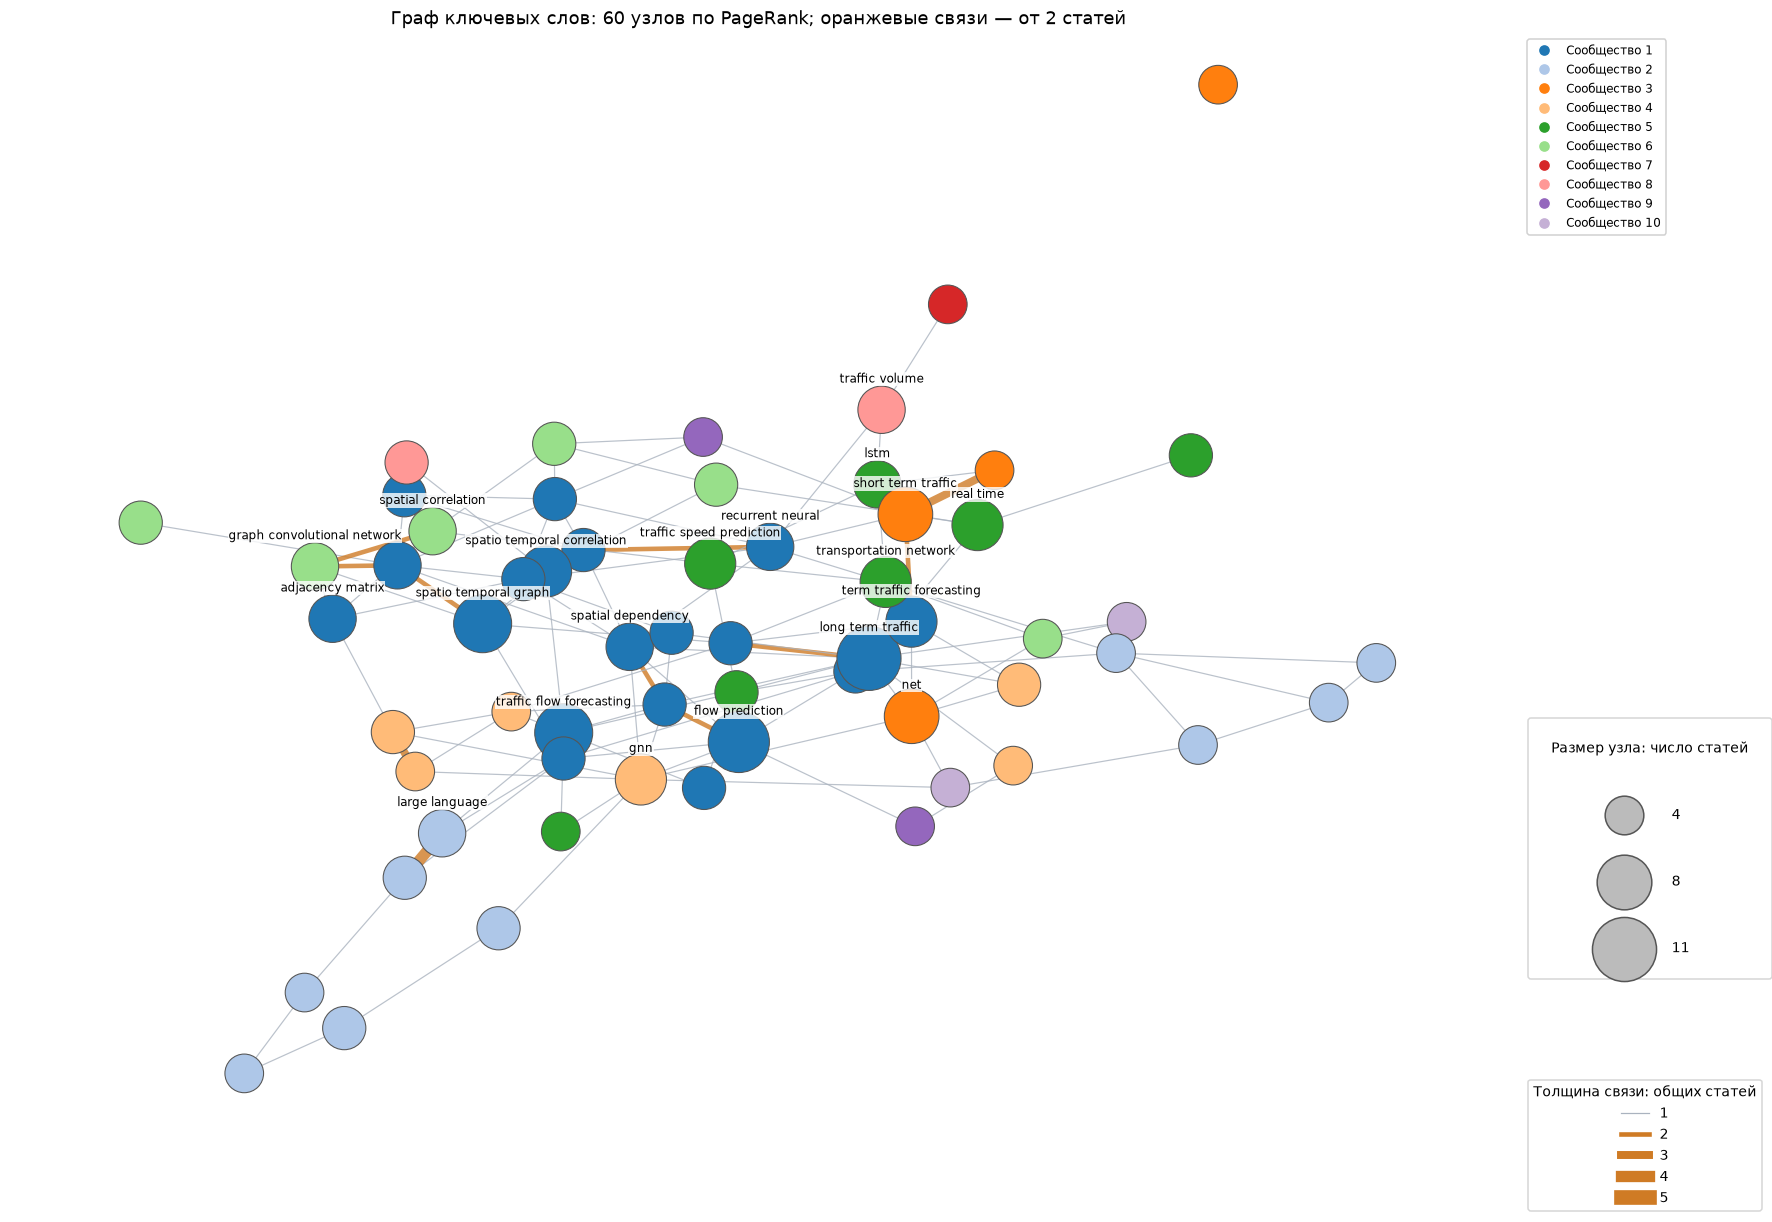

In [15]:
visible_terms = sorted(keyword_graph, key=lambda term: (-pagerank[term], term))[:60]
visible_graph = keyword_graph.subgraph(visible_terms).copy()

positions = nx.spring_layout(visible_graph, seed=SEED, weight='weight', iterations=200, k=0.7)
fig, ax = plt.subplots(figsize=(16, 11), layout='constrained')
node_order = list(visible_graph)
palette = list(plt.get_cmap('tab20').colors) + list(plt.get_cmap('Set3').colors)
nx.draw_networkx_edges(visible_graph, positions, ax=ax, edge_color=['#cf7b25' if d['weight'] >= 2 else '#aab3bf' for _, _, d in visible_graph.edges(data=True)], alpha=0.8,
                       width=[0.8 + 2.2 * (d['weight'] - 1) for _, _, d in visible_graph.edges(data=True)])
nx.draw_networkx_nodes(visible_graph, positions, ax=ax, nodelist=node_order,
                       node_color=[palette[community_id[t] - 1] for t in node_order],
                       node_size=[160 * keyword_graph.nodes[t]['document_count'] for t in node_order],
                       edgecolors='#555555', linewidths=0.7)
label_positions = {t: (x, y + 0.055) for t, (x, y) in positions.items()}
nx.draw_networkx_labels(visible_graph, label_positions, ax=ax,
                        labels={t: t for t in visible_terms[:20]}, font_size=8,
                        bbox={'facecolor': 'white', 'alpha': 0.8, 'edgecolor': 'none', 'pad': 0.5})
from matplotlib.lines import Line2D
visible_communities = sorted({community_id[t] for t in visible_terms})
community_legend = ax.legend(handles=[Line2D([0], [0], marker='o', color='w', markerfacecolor=palette[c-1],
                          markersize=8, label=f'Сообщество {c}') for c in visible_communities],
          loc='upper left', bbox_to_anchor=(1.01, 1), fontsize=8, framealpha=0.9)
ax.add_artist(community_legend)
node_examples = sorted({keyword_graph.nodes[t]['document_count'] for t in visible_terms})
node_examples = sorted({node_examples[0], node_examples[len(node_examples)//2], node_examples[-1]})
size_legend = ax.legend(handles=[ax.scatter([], [], s=160 * count, facecolor='#bbbbbb',
                                          edgecolor='#555555', label=str(count)) for count in node_examples],
                        title='Размер узла: число статей', loc='upper left',
                        bbox_to_anchor=(1.01, 0.40), fontsize=9, title_fontsize=9,
                        labelspacing=3.8, borderpad=1.7, handletextpad=2.5)
ax.add_artist(size_legend)
edge_examples = sorted({d['weight'] for _, _, d in visible_graph.edges(data=True)})
ax.legend(handles=[Line2D([0], [0], color='#cf7b25' if weight >= 2 else '#aab3bf',
                          linewidth=0.8 + 2.2 * (weight - 1), label=str(weight)) for weight in edge_examples],
          title='Толщина связи: общих статей', loc='upper left',
          bbox_to_anchor=(1.01, 0.08), fontsize=9, title_fontsize=9)
ax.set_title('Граф ключевых слов: 60 узлов по PageRank; оранжевые связи — от 2 статей')
ax.axis('off')
fig.savefig(FIGURES / 'keyword_graph.png', dpi=160, bbox_inches='tight')
plt.show()

### Выводы по графу

Получаю 1 999 терминов, 14 143 ребра и одну компоненту. При `resolution=1` было бы 24 сообщества (Q=0,617), при 0,3 — четыре, из которых одно содержит 1 434 узла (Q=0,315); при 0,4 — шесть с Q=0,506. Выбираю 0,5: десять групп по 55–514 узлов и Q=0,586. Все значения Q рассчитаны при фиксированном разрешении 1. Укрупнение облегчает интерпретацию ценой меньшей модулярности; это не десять строго отделённых научных направлений.

Кратко интерпретирую все десять сообществ по ведущим терминам. Названия условные: часть групп объединяет несколько подтем.

- **1 — пространственно-временные зависимости:** графы, матрицы смежности и рекуррентные сети; широкая группа методов прогноза.
- **2 — языковые модели и перенос между городами:** `llm`, `large language`, `cross city`; группа смешанная, включает также неопределённость и другие модели.
- **3 — краткосрочный прогноз и ансамбли:** `short term traffic`, `multi scale`, `competition`; объединяет разные архитектуры, включая решения Traffic4cast.
- **4 — графовые нейросети и данные датчиков:** `gnn`, `stgnns`, `traffic sensor`; прогноз пространственно-временных данных на дорожном графе.
- **5 — прогноз скорости:** `traffic speed prediction`, `real time`, `lstm`, `mamba`; общая задача, но разные архитектуры.
- **6 — графовые методы, перенос и федеративное обучение:** `graph convolutional network`, `transfer learning`, `federated learning`; не только федеративные модели.
- **7 — адаптация и устойчивость:** `cross domain`, `adversarial training`, `adversarial attack`; группа неоднородна, содержит также секундный прогноз и Traffic4cast.
- **8 — объём потока, колебания и эксперты:** `traffic volume`, `fluctuation`, `expert`, `mean square error`; смешаны задача, архитектурные элементы и оценка ошибок.
- **9 — обзоры и обобщение моделей:** `survey`, `prediction literature`, `generalization`, `online`; смешаны обзорные работы и отдельные методы.
- **10 — временные ряды и прогноз по дорожной сети:** `time series`, `graph convolution network`, `network wide traffic`; небольшая группа с общими терминами прогнозирования.

Центральности не являются четырьмя независимыми оценками. При десяти тегах на статью сумма весов узла равна **9 × числу статей с тегом**; 98,9% рёбер имеют вес 1, поэтому степень и PageRank тоже близки к частотному ранжированию. Лидер `long term traffic` выбран в 11 статьях, а не во всём корпусе. Снижение `max_df` не устранило совпадение лидеров.

Различия видны по посредничеству: `short term traffic` занимает 6-е место по степени и 3-е по посредничеству; `traffic flow forecasting` — 3-е и 6-е. У `long range` ранги 36 и 19, у `graph convolutional network` — 20 и 12: они чаще соединяют кратчайшие пути, чем можно ожидать только по числу соседей. Это структурная роль, не доказательство научной значимости.

Полные таблицы центральностей и сообществ сохраняю в `data/keyword_centralities.csv` и `data/keyword_communities.csv`, граф — в `data/keyword_graph.gexf`.

## 9. Граф публикаций и поиск

Узел — статья, вес ребра — число общих выбранных тегов. Сохраняю совпадения для объяснения выдачи; все статьи включаю в граф.

Ранжирую непосредственных соседей сначала по числу общих тегов, затем, при равенстве, по косинусному сходству TF-IDF заголовков и аннотаций. Полностью равные оценки разрешаю по ID. Это особенно важно для многочисленных рёбер веса 1: отбираю наиболее близкие по тексту статьи, а не первые по номеру. Исходную статью исключаю; неизвестный ID и отсутствие соседей дают пустую таблицу с сообщением.

Пять результатов — фиксированный размер выдачи для P@5, а не граница релевантности. На рисунок попадают запрос и статьи, выбранные по двум указанным критериям. Статья без общих тегов не попадёт в гибридную выдачу, даже если близка по тексту.

In [16]:
from collections import defaultdict

publication_graph = nx.Graph()
term_articles = defaultdict(list)
for article in article_keywords:
    article_id = article['arxiv_id']
    tags = sorted({item['term'] for item in article['keywords']})
    publication_graph.add_node(article_id, title=article['title'], keyword_count=len(tags))
    for term in tags:
        term_articles[term].append(article_id)

shared_by_pair = defaultdict(list)
for term, ids in sorted(term_articles.items()):
    for left, right in combinations(sorted(ids), 2):
        shared_by_pair[(left, right)].append(term)
for (left, right), shared in sorted(shared_by_pair.items()):
    publication_graph.add_edge(left, right, weight=len(shared), common_keywords=shared)

text_vectorizer = TfidfVectorizer(stop_words='english', ngram_range=(1, 2),
                                 min_df=2, max_df=0.95, sublinear_tf=True, norm='l2')
text_matrix = text_vectorizer.fit_transform([r['title'] + '. ' + r['abstract'] for r in corpus])
corpus_by_id = {r['arxiv_id']: r for r in corpus}
text_ids = [r['arxiv_id'] for r in corpus]
text_index = {article_id: i for i, article_id in enumerate(text_ids)}

# L2-нормированные векторы: скалярное произведение равно косинусному сходству.
text_similarities = (text_matrix @ text_matrix.T).toarray()
for left, right, attributes in publication_graph.edges(data=True):
    attributes['text_similarity'] = float(text_similarities[text_index[left], text_index[right]])

publication_components = sorted(nx.connected_components(publication_graph), key=len, reverse=True)
publication_isolates = sorted(nx.isolates(publication_graph))
print(f'Статей: {publication_graph.number_of_nodes()}; связей: {publication_graph.number_of_edges()}')
print(f'Компонент: {len(publication_components)}; крупнейшая: {len(publication_components[0])}; без соседей: {len(publication_isolates)}')
print('Распределение связей по числу общих тегов:', dict(sorted(Counter(d['weight'] for _, _, d in publication_graph.edges(data=True)).items())))

pd.DataFrame([{'source': left, 'target': right, 'weight': d['weight'],
               'common_keywords': json.dumps(d['common_keywords'], ensure_ascii=False),
               'text_similarity': d['text_similarity']}
              for left, right, d in publication_graph.edges(data=True)]).to_csv(DATA / 'publication_edges.csv', index=False)
pd.DataFrame([{'arxiv_id': article_id, **attrs, 'neighbors': publication_graph.degree(article_id)}
              for article_id, attrs in publication_graph.nodes(data=True)]).to_csv(DATA / 'publication_nodes.csv', index=False)
# Для GEXF преобразую список общих тегов в JSON-строку.
export_graph = publication_graph.copy()
for left, right, attrs in export_graph.edges(data=True):
    attrs['common_keywords'] = json.dumps(attrs['common_keywords'], ensure_ascii=False)
nx.write_gexf(export_graph, DATA / 'publication_graph.gexf')

Статей: 318; связей: 1732
Компонент: 1; крупнейшая: 318; без соседей: 0
Распределение связей по числу общих тегов: {1: 1613, 2: 101, 3: 11, 4: 6, 6: 1}


In [17]:
def find_similar_papers(arxiv_id, top_k=5, graph=None):
    """Ранжирую соседей по общим тегам, затем по косинусному сходству текстов."""
    if not isinstance(top_k, int) or isinstance(top_k, bool) or top_k < 1:
        raise ValueError('top_k должен быть положительным целым числом.')
    graph = publication_graph if graph is None else graph
    article_id = str(arxiv_id).strip()
    columns = ['arxiv_id', 'title', 'shared_count', 'text_similarity', 'common_keywords', 'url']
    if article_id not in graph:
        result = pd.DataFrame(columns=columns)
        result.attrs['message'] = f'ID {article_id} не найден в корпусе.'
        return result
    ranked = sorted(((neighbor, graph[article_id][neighbor]) for neighbor in graph.neighbors(article_id)
                     if neighbor != article_id), key=lambda pair: (-pair[1]['weight'], -pair[1]['text_similarity'], pair[0]))[:top_k]
    result = pd.DataFrame([
        {'arxiv_id': neighbor, 'title': graph.nodes[neighbor]['title'],
         'shared_count': attrs['weight'], 'text_similarity': attrs['text_similarity'], 'common_keywords': ', '.join(attrs['common_keywords']),
         'url': f'https://arxiv.org/abs/{neighbor}'}
        for neighbor, attrs in ranked
    ], columns=columns)
    result.attrs['message'] = (f'Найдено соседей: {graph.degree(article_id)}; показано: {len(result)}.'
                               if ranked else f'У статьи {article_id} нет соседей по выбранным тегам.')
    return result

# ID исходной статьи для поиска.
query_id = '2302.08658'
search_results = find_similar_papers(query_id, top_k=5)
print('Исходная статья:', query_id, publication_graph.nodes[query_id]['title'] if query_id in publication_graph else '')
print(search_results.attrs['message'])
with pd.option_context('display.max_colwidth', 110):
    display(search_results[['arxiv_id', 'title', 'shared_count', 'text_similarity', 'common_keywords']])
search_results.to_csv(DATA / 'publication_search_example.csv', index=False)

Исходная статья: 2302.08658 Online Spatio-Temporal Correlation-Based Federated Learning for Traffic Flow Forecasting
Найдено соседей: 18; показано: 5.


,arxiv_id,title,shared_count,text_similarity,common_keywords
0,2507.09805,Federated Learning with Graph-Based Aggregation for Traffic Forecasting,4,0.251444,"central server, client, federated learning, fl"
1,2407.12226,Individualized Federated Learning for Traffic Prediction with Error Driven Aggregation,2,0.160763,"federated learning, fl"
2,2512.24625,AutoFed: Personalized Federated Traffic Prediction via Adaptive Prompt,2,0.153948,"client, federated learning"
3,2005.05069,Transfer Learning and Online Learning for Traffic Forecasting under Different Data Availability Conditions...,1,0.163218,batch learning
4,2508.04517,Channel-Independent Federated Traffic Prediction,1,0.147559,client


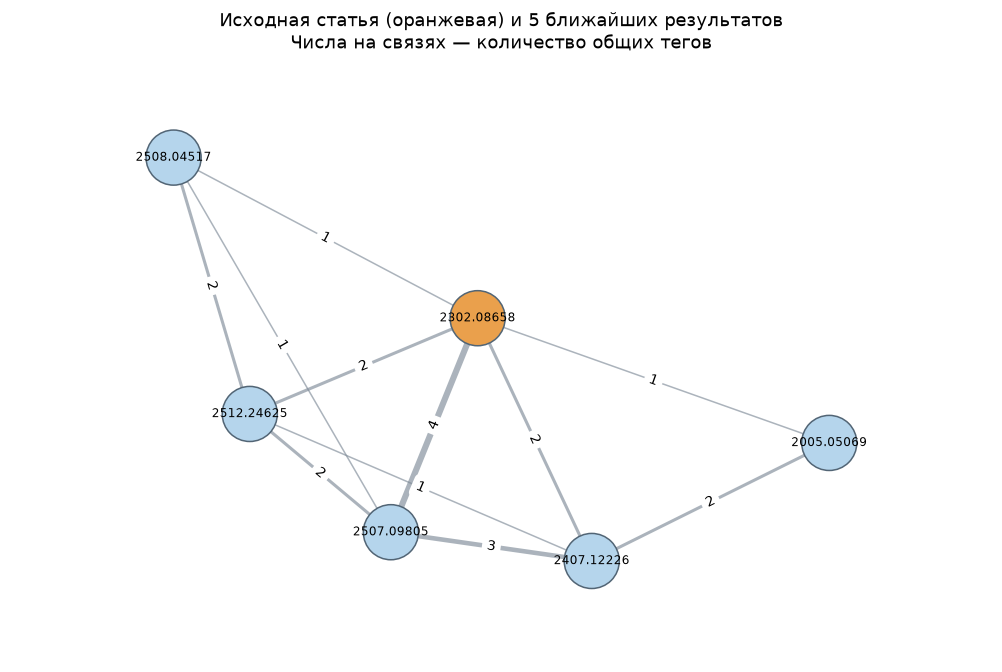

In [18]:
if query_id not in publication_graph or search_results.empty:
    print('Нет результатов для построения окружения статьи.')
else:
    # Показываю исходную статью и результаты поиска.
    shown_ids = [query_id] + search_results['arxiv_id'].tolist()
    local_graph = publication_graph.subgraph(shown_ids).copy()
    # Фиксирую порядок узлов и seed для воспроизводимого расположения.
    plot_graph = nx.Graph()
    plot_graph.add_nodes_from(sorted(local_graph.nodes(data=True)))
    plot_graph.add_edges_from(sorted(local_graph.edges(data=True)))
    local_positions = nx.spring_layout(plot_graph, seed=SEED, weight='weight', k=1.2, iterations=150)
    fig, ax = plt.subplots(figsize=(9, 6), layout='constrained')
    nx.draw_networkx_edges(plot_graph, local_positions, ax=ax, edge_color='#7f8b98', alpha=0.65,
                           width=[d['weight'] for _, _, d in plot_graph.edges(data=True)])
    nx.draw_networkx_nodes(plot_graph, local_positions, ax=ax, node_size=1300,
                           node_color=['#eaa04c' if node == query_id else '#b5d5ec' for node in plot_graph],
                           edgecolors='#526575')
    nx.draw_networkx_labels(plot_graph, local_positions, ax=ax, font_size=8)
    nx.draw_networkx_edge_labels(plot_graph, local_positions, ax=ax,
                                 edge_labels=nx.get_edge_attributes(plot_graph, 'weight'), font_size=9)
    ax.set_title(f'Исходная статья (оранжевая) и {len(search_results)} ближайших результатов\nЧисла на связях — количество общих тегов')
    ax.margins(0.18)
    ax.axis('off')
    fig.savefig(FIGURES / 'publication_search.png', dpi=160, bbox_inches='tight')
    plt.show()


### Выводы по поиску

Получаю 318 узлов и 1 732 связи; граф связный. У 93,1% связанных пар совпадает один тег, поэтому разрешение равных весов по тексту существенно для выбора результатов.

Для `2302.08658` нахожу 18 соседей. Первой остаётся `2507.09805` с четырьмя общими тегами. Среди соседей веса 1 TF-IDF выбирает `2005.05069` (0,163) и `2508.04517` (0,148); прежняя `2104.00055` с неоднозначным тегом `aggregation mechanism` больше не входит в пятёрку. Общий тег объясняет наличие связи, а косинусное сходство — выбор внутри одинакового веса.

Ограничение: `fl` и `federated learning` считаются разными тегами, хотя обозначают одно понятие. Вес остаётся первым критерием: больше общих тегов всегда имеет приоритет над текстовым сходством.

Запрос задаю в `query_id`, размер выдачи — через `top_k`. На рисунке оранжевый узел — запрос, остальные — результаты; числа на связях — общие теги. В таблице дополнительно показываю `text_similarity`. Граф, таблицы и пример выдачи сохраняю в `data/publication_graph.gexf`, `publication_nodes.csv`, `publication_edges.csv`, `publication_search_example.csv`.

## 10. Проверка поиска и итоговые выводы

Сравниваю гибридный графовый поиск с поиском по косинусному сходству всех статей корпуса. Оба используют одно текстовое представление: TF-IDF исходных заголовков и аннотаций, униграммы и биграммы, английские стоп-слова, `min_df=2`, `max_df=0.95`, логарифмическую TF и L2-нормировку. Гибрид ограничивает кандидатов соседями и сначала сравнивает число тегов; текстовый метод ранжирует весь корпус по косинусу. Оба исключают запрос и возвращают пять результатов.

Запросы: `2302.08658` — федеративное обучение, `2001.02908` — Transformer/attention, `2401.10155` — адаптивные графы. В объединении текущих выдач 22 пары «запрос — результат».

По названиям и аннотациям ставлю **2** за близкое методическое направление, **1** за частичное совпадение, **0** за совпадение только общей области. Для новых результатов дополняю `data/search_relevance.csv`, прежние оценки сохраняю. P@5 — доля оценок 2; дополнительно считаю долю оценок ≥1 и средний балл. Итог усредняю по трём запросам.

In [19]:
query_topics = {
    '2302.08658': 'Федеративное обучение',
    '2001.02908': 'Transformer / attention',
    '2401.10155': 'Адаптивные графы',
}

def text_search(arxiv_id, top_k=5):
    if not isinstance(top_k, int) or isinstance(top_k, bool) or top_k < 1:
        raise ValueError('top_k должен быть положительным целым числом.')
    if arxiv_id not in text_index:
        return []
    scores = (text_matrix[text_index[arxiv_id]] @ text_matrix.T).toarray().ravel()
    return sorted([(article_id, float(score)) for article_id, score in zip(text_ids, scores)
                   if article_id != arxiv_id and score > 0], key=lambda pair: (-pair[1], pair[0]))[:top_k]

retrieval_rows = []
for query_id in query_topics:
    graph_results = find_similar_papers(query_id, top_k=5)
    graph_ranked = list(zip(graph_results['arxiv_id'], graph_results['shared_count']))
    for method, ranked in [('Граф + TF-IDF', graph_ranked), ('Текст TF-IDF', text_search(query_id))]:
        for rank, (article_id, score) in enumerate(ranked, 1):
            retrieval_rows.append({'query_id': query_id, 'method': method, 'rank': rank,
                                   'article_id': article_id, 'score': score,
                                   'text_similarity': float(text_similarities[text_index[query_id], text_index[article_id]]),
                                   'title': corpus_by_id[article_id]['title']})
retrieval = pd.DataFrame(retrieval_rows)
print(f'Текстовый словарь: {text_matrix.shape[1]} признаков; результатов: {len(retrieval)}')

Текстовый словарь: 6093 признаков; результатов: 30


In [20]:
judgments = pd.read_csv(DATA / 'search_relevance.csv', dtype={'query_id': str, 'article_id': str}, encoding='utf-8-sig')
# Проверяю, что оценки относятся к текущим версиям текстов.
def source_digest(record):
    return hashlib.sha256((record['title'] + '\n' + record['abstract']).encode()).hexdigest()

for row in judgments.itertuples():
    assert source_digest(corpus_by_id[row.query_id]) == row.query_text_sha256, 'Изменён текст запроса: обновите оценки.'
    assert source_digest(corpus_by_id[row.article_id]) == row.article_text_sha256, 'Изменена аннотация: обновите оценки.'
evaluated = retrieval.merge(judgments[['query_id', 'article_id', 'relevance', 'reason', 'evidence_url']],
                            on=['query_id', 'article_id'], how='left', validate='many_to_one')
assert evaluated['relevance'].notna().all(), 'Есть новые результаты без оценки: сначала прочитайте аннотации.'
assert evaluated['relevance'].isin([0, 1, 2]).all()
evaluated.to_csv(DATA / 'search_evaluation.csv', index=False)
metric_rows = []
for (query_id, method), group in evaluated.groupby(['query_id', 'method'], sort=False):
    assert len(group) == 5
    metric_rows.append({'query_id': query_id, 'topic': query_topics[query_id], 'method': method,
                        'P@5': (group.relevance == 2).sum() / 5,
                        'relevance>=1@5': (group.relevance >= 1).sum() / 5,
                        'mean_grade': group.relevance.mean()})
search_metrics = pd.DataFrame(metric_rows)
search_metrics.to_csv(DATA / 'search_metrics.csv', index=False)
display(search_metrics.rename(columns={'topic': 'Подтема', 'method': 'Метод',
                                       'relevance>=1@5': 'Доля с оценкой ≥1', 'mean_grade': 'Средний балл'}).drop(columns='query_id'))
print('Среднее по трём запросам:')
display(search_metrics.groupby('method')[['P@5', 'relevance>=1@5', 'mean_grade']].mean().round(3))

,Подтема,Метод,P@5,Доля с оценкой ≥1,Средний балл
0,Федеративное обучение,Граф + TF-IDF,0.8,1.0,1.8
1,Федеративное обучение,Текст TF-IDF,0.8,1.0,1.8
2,Transformer / attention,Граф + TF-IDF,0.8,1.0,1.8
3,Transformer / attention,Текст TF-IDF,0.8,1.0,1.8
4,Адаптивные графы,Граф + TF-IDF,0.8,1.0,1.8
5,Адаптивные графы,Текст TF-IDF,0.6,1.0,1.6


Среднее по трём запросам:


,P@5,relevance>=1@5,mean_grade
method,,,
Граф + TF-IDF,0.800,1.0,1.800
Текст TF-IDF,0.733,1.0,1.733


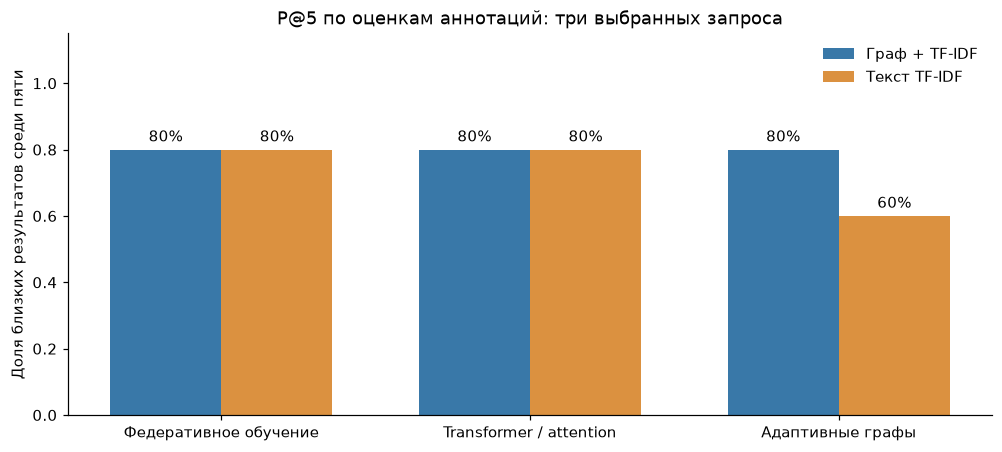

In [21]:
fig, ax = plt.subplots(figsize=(9, 4), layout='constrained')
comparison = search_metrics.pivot(index='topic', columns='method', values='P@5').reindex(list(query_topics.values()))
x = np.arange(len(comparison))
for shift, method, color in [(-0.18, 'Граф + TF-IDF', '#3978a8'), (0.18, 'Текст TF-IDF', '#db9140')]:
    bars = ax.bar(x + shift, comparison[method], width=0.36, label=method, color=color)
    ax.bar_label(bars, labels=[f'{v:.0%}' for v in comparison[method]], padding=3)
ax.set_xticks(x, comparison.index)
ax.set_ylim(0, 1.15)
ax.set_ylabel('Доля близких результатов среди пяти')
ax.set_title('P@5 по оценкам аннотаций: три выбранных запроса')
ax.legend(frameon=False)
fig.savefig(FIGURES / 'search_comparison.png', dpi=160, bbox_inches='tight')
plt.show()

### Итоговые выводы

Гибридный поиск даёт P@5=0,8 на каждом из трёх запросов: **12 близких результатов из 15**. У текстового TF-IDF — 11 из 15 (0,733). Все результаты обоих методов имеют хотя бы частичное соответствие; средние баллы — 1,8 и 1,733 из 2. До разрешения равных весов по косинусу графовый поиск давал 8 из 15.

Для федеративного запроса в пятёрку входит Fed-CI (`2508.04517`) вместо SST-GNN (`2104.00055`), где агрегация относилась к дорожным узлам. Для Transformer появляется HUTFormer (`2307.14596`); STGCGRN (`2210.02737`) остаётся частичным совпадением: attention дополняет GCN/GRU, а не пространственно-временной Transformer. Для адаптивных графов DT-SGN (`2302.10428`) и ADMFormer (`2605.25543`) описывают зависимости, меняющиеся с входными данными.

На этих примерах гибрид улучшил выдачу и сохранил объяснение через общие теги. Разница с текстовым поиском составляет одну позицию и не доказывает превосходство в целом: запросов только три, разметка субъективна, запросы уже использовались при подборе и проверке обработки. Это проверка разработки, а не независимый тест.

Корпус содержит 318 публикаций; построены частотный анализ, ключевые слова, два графа и поиск. Десять сообществ удобнее для просмотра, но часть групп содержательно смешана. Центральности характеризуют структуру графа, а не качество научных методов.

Оценки — `data/search_relevance.csv`, выдача с оценками — `data/search_evaluation.csv`, метрики — `data/search_metrics.csv`, график — `data/figures/search_comparison.png`. Контрольные суммы текстов проверяют актуальность разметки.